# Classification Model - HDB Town Prediction (KNN, Random Forest, XGBM, Light GBM and Cat Boost)

A step-by-step guide for building and evaluating K-Nearest Neighbors classification models.

**Objective:** Classify HDB towns based on property and location features.

---

## Step 1: Identify the Target Variable (y)

Define the categorical variable you want to predict (the dependent variable).

In [2]:
# ========== MODIFY THIS ==========
TARGET_COLUMN = 'town'  # Categorical target: town classification

# Note: TARGET_MAPPING will be created dynamically after loading data
# since there are many towns in Singapore
TARGET_MAPPING = None  # Will be populated in Step 3
# =================================

---

## Step 2: Import Packages and Load Dataset

In [3]:
# Import required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

from sklearn import metrics
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Optional boosting libraries
try:
    from xgboost import XGBClassifier
except ImportError:
    XGBClassifier = None

try:
    from catboost import CatBoostClassifier
except ImportError:
    CatBoostClassifier = None

try:
    from lightgbm import LGBMClassifier
except ImportError:
    LGBMClassifier = None

# Configure plot settings
plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['font.size'] = 14
plt.style.use("fivethirtyeight")

# Suppress warnings
warnings.filterwarnings('ignore')

print("Packages imported successfully!")

Packages imported successfully!


In [4]:
# ========== MODIFY THIS ==========
# Load your dataset
DATA_PATH = '../Data/data.csv'
# =================================

df = pd.read_csv(DATA_PATH)

# Create TARGET_MAPPING dynamically from unique town values
TARGET_MAPPING = {town: idx for idx, town in enumerate(sorted(df[TARGET_COLUMN].unique()))}
print(f"Towns found: {len(TARGET_MAPPING)}")
print(f"Town mapping: {TARGET_MAPPING}")

# Preview the data
print(f"\nDataset loaded with shape: {df.shape}")
df.head()

Towns found: 26
Town mapping: {'ANG MO KIO': 0, 'BEDOK': 1, 'BISHAN': 2, 'BUKIT BATOK': 3, 'BUKIT MERAH': 4, 'BUKIT PANJANG': 5, 'BUKIT TIMAH': 6, 'CENTRAL AREA': 7, 'CHOA CHU KANG': 8, 'CLEMENTI': 9, 'GEYLANG': 10, 'HOUGANG': 11, 'JURONG EAST': 12, 'JURONG WEST': 13, 'KALLANG/WHAMPOA': 14, 'MARINE PARADE': 15, 'PASIR RIS': 16, 'PUNGGOL': 17, 'QUEENSTOWN': 18, 'SEMBAWANG': 19, 'SENGKANG': 20, 'SERANGOON': 21, 'TAMPINES': 22, 'TOA PAYOH': 23, 'WOODLANDS': 24, 'YISHUN': 25}

Dataset loaded with shape: (270619, 76)


,Tranc_YearMonth,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price,...,vacancy,pri_sch_affiliation,pri_sch_latitude,pri_sch_longitude,sec_sch_nearest_dist,sec_sch_name,cutoff_point,affiliation,sec_sch_latitude,sec_sch_longitude
0,2012-03,ANG MO KIO,5 ROOM,101,ANG MO KIO AVE 3,06 TO 10,117.0,Standard,1978,515000.0,...,61.0,0.0,1.369092,103.839041,474.789674,Ang Mo Kio Secondary School,224.0,0.0,1.367359,103.842600
1,2012-03,ANG MO KIO,3 ROOM,103,ANG MO KIO AVE 3,06 TO 10,73.0,New Generation,1978,368000.0,...,61.0,0.0,1.369092,103.839041,522.935557,Mayflower Secondary School,219.0,0.0,1.368337,103.835439
2,2012-03,ANG MO KIO,4 ROOM,105,ANG MO KIO AVE 4,06 TO 10,92.0,New Generation,1978,430000.0,...,61.0,0.0,1.369092,103.839041,398.421190,CHIJ Saint Nicholas Girls' School,256.0,1.0,1.373730,103.834309
3,2012-03,ANG MO KIO,4 ROOM,108,ANG MO KIO AVE 4,06 TO 10,92.0,New Generation,1978,427000.0,...,61.0,0.0,1.369092,103.839041,424.046635,Mayflower Secondary School,219.0,0.0,1.368337,103.835439
4,2012-03,ANG MO KIO,3 ROOM,110,ANG MO KIO AVE 4,01 TO 05,67.0,New Generation,1978,323000.0,...,61.0,0.0,1.369092,103.839041,322.732547,Mayflower Secondary School,219.0,0.0,1.368337,103.835439


---

## Step 3: Explore the Dataset Structure

Check the number of features, data types, and basic statistics.

In [5]:
# Check dimensions (rows, columns)
print(f"Dataset shape: {df.shape}")
print(f"Number of features: {df.shape[1]}")
print("\n" + "="*50)

# Check for missing values
print("\nMissing values per column:")
missing = df.isnull().sum()
print(missing[missing > 0])

# View column names and data types
print("\nColumn Info:")
df.info()

Dataset shape: (270619, 76)
Number of features: 76


Missing values per column:
Mall_Nearest_Distance      5210
Mall_Within_500m         168137
Mall_Within_1km           49132
Mall_Within_2km            7036
Hawker_Within_500m       177013
Hawker_Within_1km        109046
Hawker_Within_2km         52516
dtype: int64

Column Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270619 entries, 0 to 270618
Data columns (total 76 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Tranc_YearMonth            270619 non-null  object 
 1   town                       270619 non-null  object 
 2   flat_type                  270619 non-null  object 
 3   block                      270619 non-null  object 
 4   street_name                270619 non-null  object 
 5   storey_range               270619 non-null  object 
 6   floor_area_sqm             270619 non-null  float64
 7   flat_model                 270619 non-nu

In [6]:
# View basic statistics
df.describe()

,floor_area_sqm,lease_commence_date,resale_price,Tranc_Year,Tranc_Month,mid_storey,lower,upper,mid,floor_area_sqft,...,pri_sch_nearest_distance,vacancy,pri_sch_affiliation,pri_sch_latitude,pri_sch_longitude,sec_sch_nearest_dist,cutoff_point,affiliation,sec_sch_latitude,sec_sch_longitude
count,270619.000000,270619.000000,2.706190e+05,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,...,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000
mean,96.688538,1994.860209,5.077318e+05,2019.382867,6.569993,8.540509,7.520218,9.560800,8.540509,1040.751170,...,410.333804,49.501099,0.110421,1.367462,103.839956,524.446040,119.498162,0.036088,1.367066,103.840203
std,24.158391,13.743470,1.758274e+05,3.938842,3.322633,5.753127,5.757832,5.751876,5.753127,260.039993,...,246.979262,20.722907,0.313414,0.042797,0.071881,315.536641,97.268801,0.186509,0.042629,0.071779
min,31.000000,1966.000000,1.500000e+05,2012.000000,1.000000,2.000000,1.000000,3.000000,2.000000,333.680900,...,42.554863,0.000000,0.000000,1.274962,103.687588,38.913475,5.000000,0.000000,1.276029,103.687207
25%,76.000000,1984.000000,3.800000e+05,2016.000000,4.000000,5.000000,4.000000,6.000000,5.000000,818.056400,...,232.375000,32.000000,0.000000,1.337408,103.776108,297.943031,19.000000,0.000000,1.338179,103.777148
50%,93.000000,1995.000000,4.730000e+05,2020.000000,7.000000,8.000000,7.000000,9.000000,8.000000,1001.052000,...,361.106748,48.000000,0.000000,1.365518,103.844934,459.407453,188.000000,0.000000,1.367107,103.844934
75%,112.000000,2004.000000,6.038880e+05,2023.000000,9.000000,11.000000,10.000000,12.000000,11.000000,1205.556800,...,524.571779,64.000000,0.000000,1.394958,103.898773,669.551509,211.000000,0.000000,1.396218,103.899872
max,366.700000,2022.000000,1.658888e+06,2025.000000,12.000000,50.000000,49.000000,51.000000,50.000000,3947.122130,...,3306.003143,138.000000,1.000000,1.456667,103.962919,3638.977233,260.000000,1.000000,1.453280,103.961105


In [7]:
# ========== DEFINE COLUMNS TO USE ==========
# Drop rows with missing values in columns used by the model

COLUMNS_TO_USE = [
    # Core features (minimal to little empty (less than 10%))
    'Mall_Nearest_Distance',
    'mrt_nearest_distance',
    'Hawker_Nearest_Distance',
    'hdb_age',
    'max_floor_lvl',
    # Target
    'town',
]
# Note: Avoided Hawker_Within_500m (65% missing), Mall_Within_500m (62% missing)
# ===========================================

# Validate required columns are present
missing_required_cols = [col for col in COLUMNS_TO_USE if col not in df.columns]
if missing_required_cols:
    raise ValueError(f"Missing required columns in dataset: {missing_required_cols}")

# Diagnostic: show missing values for the columns used by the model
missing_before = df[COLUMNS_TO_USE].isna().sum().sort_values(ascending=False)
print("Missing values before cleanup (columns used):")
print(missing_before.to_string())
print(f"\nTotal missing values before cleanup (columns used): {int(missing_before.sum())}")

# Drop rows with any missing values in model columns (features + target)
rows_before = len(df)
df = df.dropna(subset=COLUMNS_TO_USE)
rows_after = len(df)
rows_dropped = rows_before - rows_after

missing_after = df[COLUMNS_TO_USE].isna().sum().sort_values(ascending=False)
print("\nMissing values after cleanup (columns used):")
print(missing_after.to_string())
print(f"\nTotal missing values after cleanup (columns used): {int(missing_after.sum())}")

print(f"\nRows before cleanup: {rows_before}")
print(f"Rows after cleanup: {rows_after}")
print(f"Rows dropped: {rows_dropped}")

Missing values before cleanup (columns used):
Mall_Nearest_Distance      5210
mrt_nearest_distance          0
Hawker_Nearest_Distance       0
hdb_age                       0
max_floor_lvl                 0
town                          0

Total missing values before cleanup (columns used): 5210

Missing values after cleanup (columns used):
Mall_Nearest_Distance      0
mrt_nearest_distance       0
Hawker_Nearest_Distance    0
hdb_age                    0
max_floor_lvl              0
town                       0

Total missing values after cleanup (columns used): 0

Rows before cleanup: 270619
Rows after cleanup: 265409
Rows dropped: 5210


---

## Step 3.5: Feature Engineering (Optional)

Create new features by combining or transforming existing columns. This can help capture relationships that improve model performance.

**Common feature engineering techniques for KNN:**
- **Ratio features**: e.g., `floor_ratio = mid_storey / max_floor_lvl` (relative floor position)
- **Interaction features**: e.g., `area_per_floor = floor_area_sqm / max_floor_lvl`
- **Distance scores**: e.g., combining multiple distance features

> **Note:** KNN uses distance calculations, so engineered features should be on similar scales. Feature scaling (StandardScaler) in Step 5 will handle this.

Fallback used: live_pri built from pri_sch_nearest_distance + pri_sch_affiliation
Fallback used: school_tier_encoded missing, live_sec uses proximity only
Town Liveability Rankings:

                 liveability  pri_school  sec_school    mrt  hawker   mall
town                                                                      
CENTRAL AREA           0.700       0.586       0.706  0.755   0.716  0.729
BISHAN                 0.696       0.787       0.895  0.749   0.588  0.423
BUKIT PANJANG          0.693       0.634       0.879  0.834   0.529  0.511
GEYLANG                0.684       0.788       0.829  0.685   0.658  0.453
PUNGGOL                0.662       0.674       0.877  0.887   0.218  0.486
SENGKANG               0.659       0.655       0.888  0.762   0.397  0.501
TAMPINES               0.656       0.665       0.886  0.680   0.552  0.466
HOUGANG                0.652       0.765       0.898  0.537   0.573  0.498
WOODLANDS              0.651       0.627       0.892  0.644   0.601

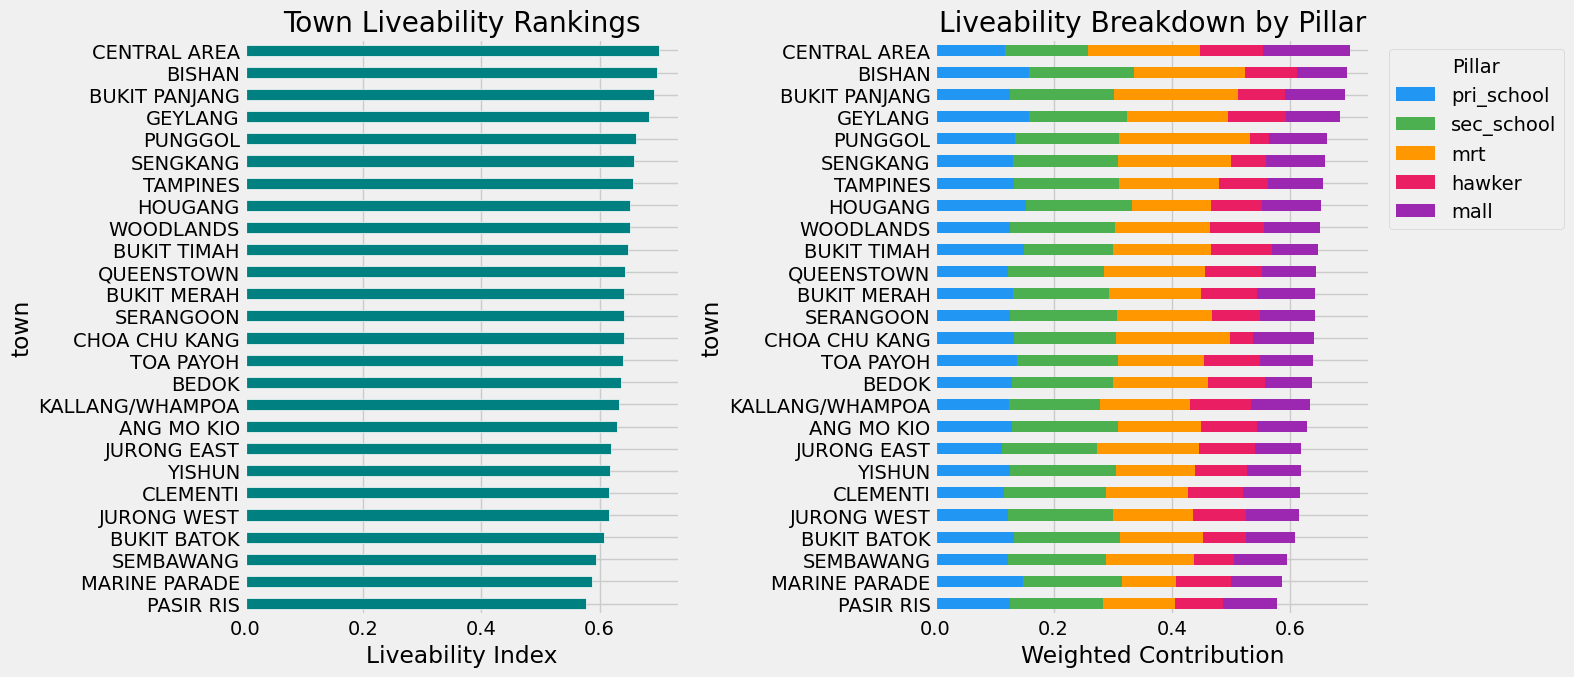

In [8]:
# ========== FEATURE ENGINEERING SECTION ==========
# Add new engineered features below. Each feature is created from existing columns.

# ============================================================
# Town Liveability Index
# ============================================================
# Combines 5 pillars - each scored 0-1 per transaction, then
# averaged per town. Within each pillar the score scales UP
# with quality/prestige AND proximity/count.


def build_liveability(df):
    df = df.copy()

    # Columns that must exist in this dataset
    required_columns = [
        'sec_sch_nearest_dist',
        'mrt_nearest_distance',
        'mrt_interchange',
        'Hawker_Nearest_Distance',
        'hawker_food_stalls',
        'Mall_Nearest_Distance',
        'Mall_Within_2km',
        'pri_sch_nearest_distance',
        'pri_sch_affiliation',
    ]
    missing = [c for c in required_columns if c not in df.columns]
    if missing:
        raise KeyError(f"Missing required columns for liveability features: {missing}")

    # Helper: min-max scale a series to [0, 1]
    def minmax(s):
        s = s.astype(float)
        span = s.max() - s.min()
        if pd.isna(span) or span == 0:
            return pd.Series(0.0, index=s.index)
        return (s - s.min()) / span

    # ---------- 1. PRIMARY SCHOOL ----------
    # Build prestige proxy from proximity + affiliation when
    # primary_school_prestige_index is unavailable.
    if 'primary_school_prestige_index' in df.columns:
        df['live_pri'] = minmax(df['primary_school_prestige_index'])
    else:
        pri_prox = minmax(df['pri_sch_nearest_distance'].max() - df['pri_sch_nearest_distance'])
        pri_aff = minmax(df['pri_sch_affiliation'].fillna(0))
        df['live_pri'] = 0.7 * pri_prox + 0.3 * pri_aff
        print("Fallback used: live_pri built from pri_sch_nearest_distance + pri_sch_affiliation")

    # ---------- 2. SECONDARY SCHOOL ----------
    sec_prox = minmax(df['sec_sch_nearest_dist'].max() - df['sec_sch_nearest_dist'])

    # Use school quality only if the column exists
    if 'school_tier_encoded' in df.columns:
        sec_qual = (2 - df['school_tier_encoded']) / 1.0   # 1 -> 1, 2 -> 0
        df['live_sec'] = 0.5 * sec_prox + 0.5 * sec_qual
    else:
        df['live_sec'] = sec_prox
        print("Fallback used: school_tier_encoded missing, live_sec uses proximity only")

    # ---------- 3. MRT ----------
    mrt_prox = minmax(df['mrt_nearest_distance'].max() - df['mrt_nearest_distance'])
    mrt_inter = df['mrt_interchange'].clip(0, 1)
    df['live_mrt'] = 0.7 * mrt_prox + 0.3 * mrt_inter

    # ---------- 4. HAWKER ----------
    hawk_prox = minmax(df['Hawker_Nearest_Distance'].max() - df['Hawker_Nearest_Distance'])
    hawk_stalls = minmax(df['hawker_food_stalls'])
    df['live_hawker'] = 0.6 * hawk_prox + 0.4 * hawk_stalls

    # ---------- 5. MALL ----------
    mall_prox = minmax(df['Mall_Nearest_Distance'].max() - df['Mall_Nearest_Distance'])
    mall_count = minmax(df['Mall_Within_2km'].fillna(0))
    df['live_mall'] = 0.5 * mall_prox + 0.5 * mall_count

    # Final transaction-level liveability index
    df['liveability_index'] = (
        0.20 * df['live_pri']
        + 0.20 * df['live_sec']
        + 0.25 * df['live_mrt']
        + 0.15 * df['live_hawker']
        + 0.20 * df['live_mall']
    )

    return df


df = build_liveability(df)

PILLARS = ['live_pri', 'live_sec', 'live_mrt', 'live_hawker', 'live_mall']
df[PILLARS] = df[PILLARS].fillna(0)

TARGET_COLUMN = 'town'
FEATURE_COLUMNS = PILLARS
df = df.dropna(subset=[TARGET_COLUMN])
df[TARGET_COLUMN] = df[TARGET_COLUMN].astype(str)

# Aggregate to town level (diagnostic view)
town_live = (
    df.groupby('town')
    .agg(
        liveability=('liveability_index', 'mean'),
        pri_school=('live_pri', 'mean'),
        sec_school=('live_sec', 'mean'),
        mrt=('live_mrt', 'mean'),
        hawker=('live_hawker', 'mean'),
        mall=('live_mall', 'mean'),
        avg_resale=('resale_price', 'mean'),
        n_transactions=('resale_price', 'size'),
    )
    .sort_values('liveability', ascending=False)
)

print('Town Liveability Rankings:\n')
print(town_live[['liveability', 'pri_school', 'sec_school', 'mrt', 'hawker', 'mall']].round(3).to_string())

# Correlation with resale_price (transaction-level)
r = df['resale_price'].corr(df['liveability_index'])
print(f"\nCorrelation between liveability_index and resale_price: {r:.4f}")

# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Bar chart: town rankings
town_live['liveability'].sort_values().plot(
    kind='barh', ax=axes[0], color='teal', edgecolor='white'
)
axes[0].set_xlabel('Liveability Index')
axes[0].set_title('Town Liveability Rankings')

# Stacked breakdown
pillar_cols = ['pri_school', 'sec_school', 'mrt', 'hawker', 'mall']
weights = [0.20, 0.20, 0.25, 0.15, 0.20]
weighted = town_live[pillar_cols].multiply(weights).loc[town_live['liveability'].sort_values().index]
weighted.plot(
    kind='barh',
    stacked=True,
    ax=axes[1],
    color=['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0'],
)
axes[1].set_xlabel('Weighted Contribution')
axes[1].set_title('Liveability Breakdown by Pillar')
axes[1].legend(title='Pillar', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

Target variable distribution (town):
town
SENGKANG           19939
WOODLANDS          19586
JURONG WEST        18831
TAMPINES           18618
YISHUN             18156
PUNGGOL            15791
BEDOK              14980
HOUGANG            13652
ANG MO KIO         11510
CHOA CHU KANG      11277
BUKIT BATOK        11214
BUKIT MERAH        10057
BUKIT PANJANG       9526
TOA PAYOH           8523
KALLANG/WHAMPOA     8045
PASIR RIS           7897
SEMBAWANG           7884
QUEENSTOWN          7057
GEYLANG             6799
CLEMENTI            6140
JURONG EAST         5621
SERANGOON           5066
BISHAN              4747
CENTRAL AREA        2147
MARINE PARADE       1717
BUKIT TIMAH          629
Name: count, dtype: int64


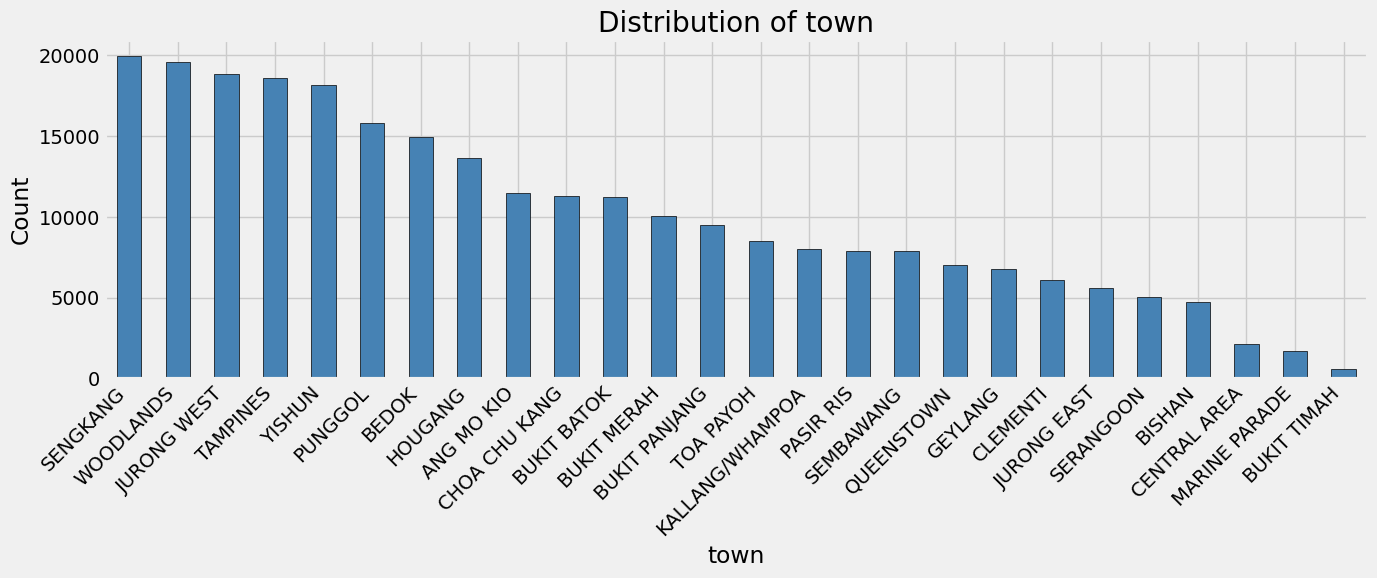

In [9]:
# Check target variable distribution
print(f"Target variable distribution ({TARGET_COLUMN}):")
print(df[TARGET_COLUMN].value_counts())

# Visualize target distribution
plt.figure(figsize=(14, 6))
df[TARGET_COLUMN].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title(f'Distribution of {TARGET_COLUMN}')
plt.xlabel(TARGET_COLUMN)
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---

## Step 4: Exploratory Data Analysis (EDA) - Feature Distributions

For KNN classification, **correlation analysis is not as important** as it is for linear models. KNN is a distance-based algorithm that doesn't assume linear relationships between features and the target.

**What matters for KNN:**
- How well features **separate the classes** (visualized with boxplots)
- Feature **scale** (addressed with StandardScaler in Step 5)
- Feature **distribution** within each class

### 4a. Feature Distribution by Target Class (Boxplots)

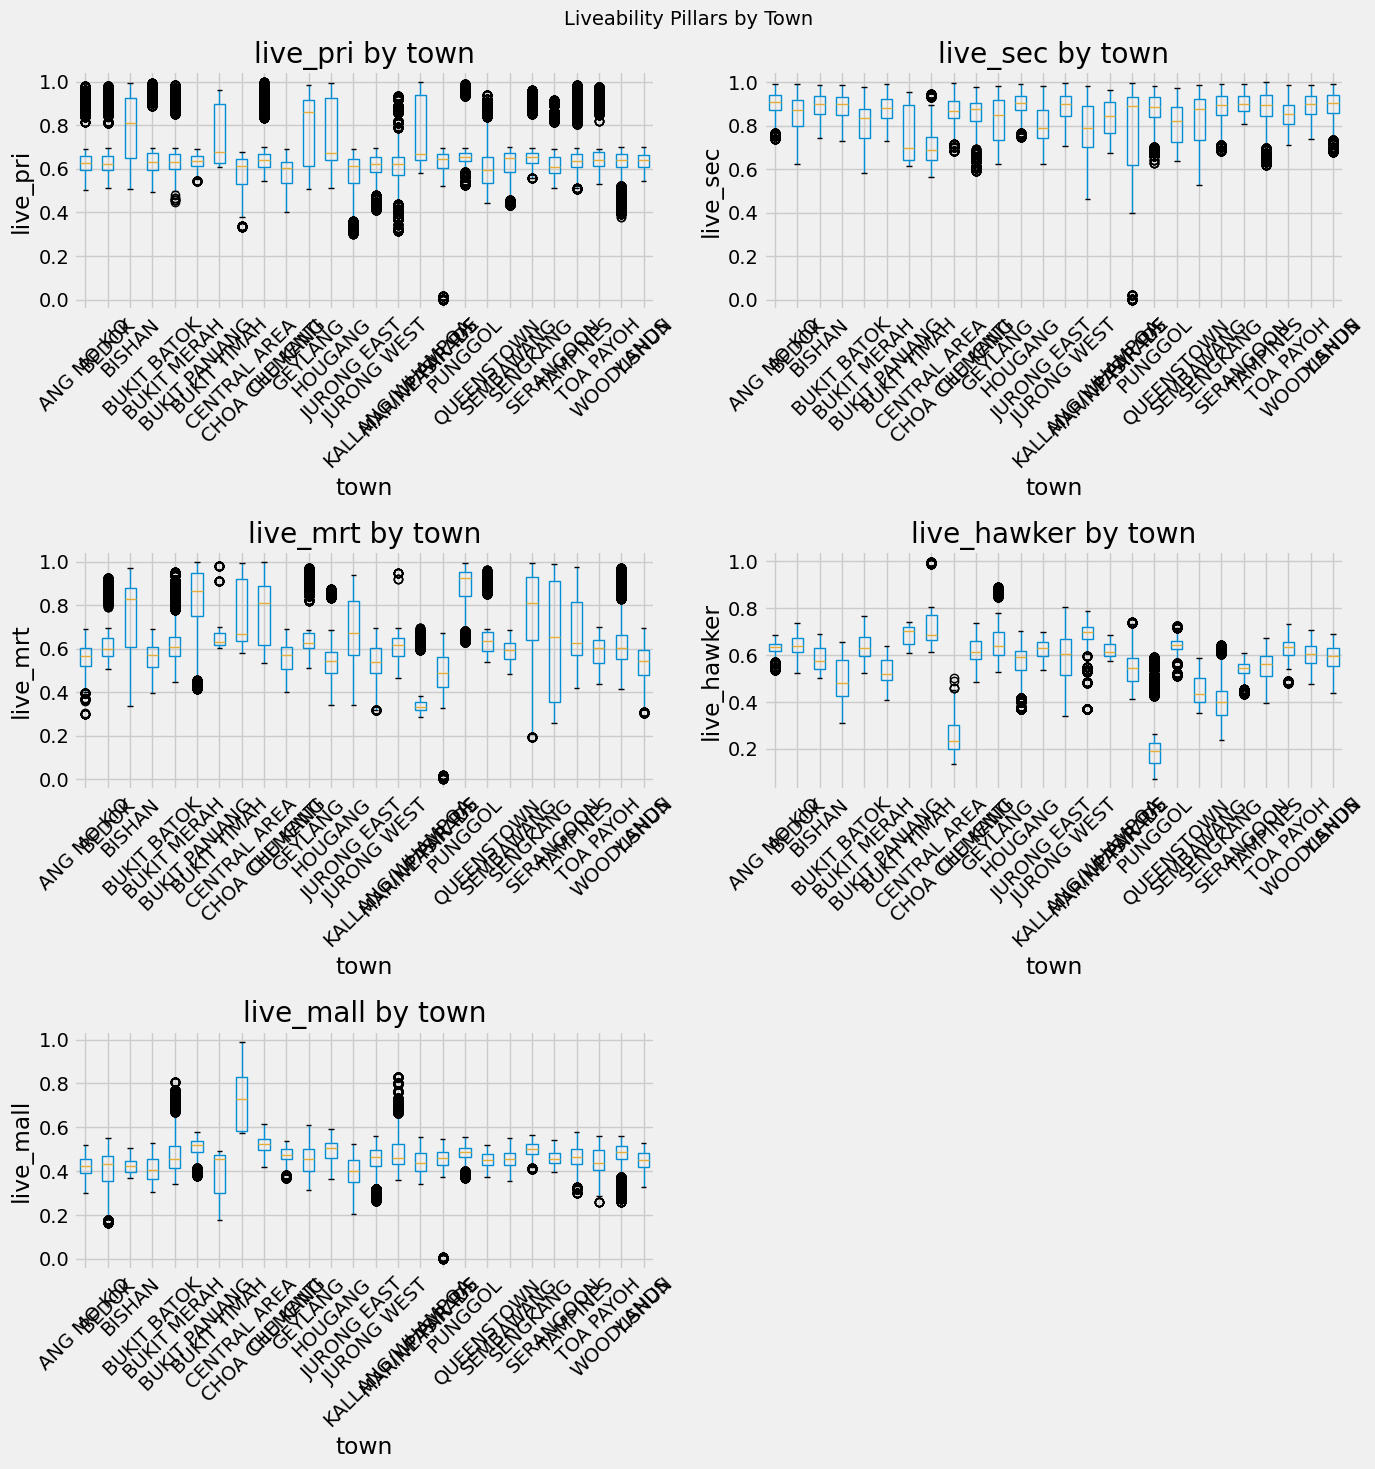

In [10]:
# ========== MODIFY THIS ==========
# Use the 5 liveability pillars for class-separation inspection
FEATURES_TO_PLOT = PILLARS
# =================================

# Box plots for key features by target class
# This shows how well each feature separates the different classes
n_features = len(FEATURES_TO_PLOT)
n_cols = 2
n_rows = (n_features + 1) // 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(FEATURES_TO_PLOT):
    if col in df.columns:
        df.boxplot(column=col, by=TARGET_COLUMN, ax=axes[i])
        axes[i].set_title(f'{col} by {TARGET_COLUMN}')
        axes[i].set_xlabel(TARGET_COLUMN)
        axes[i].set_ylabel(col)
        axes[i].tick_params(axis='x', rotation=45)

# Hide empty subplots if odd number of features
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Liveability Pillars by Town', fontsize=14)
plt.tight_layout()
plt.show()

**Interpreting Boxplots for KNN:**
- **Good features:** Show clear separation between classes (minimal overlap in boxes)
- **Less useful features:** Classes overlap significantly
- Features with better class separation will contribute more to accurate KNN predictions

### 4b. Class Separation Summary

In [11]:
# Calculate mean values per class to understand feature separation
class_means = df.groupby(TARGET_COLUMN)[FEATURES_TO_PLOT].mean()
print("Mean feature values by town:")
display(class_means.round(2))

Mean feature values by town:


,live_pri,live_sec,live_mrt,live_hawker,live_mall
town,,,,,
ANG MO KIO,0.64,0.90,0.56,0.63,0.42
BEDOK,0.65,0.86,0.64,0.64,0.40
BISHAN,0.79,0.90,0.75,0.59,0.42
BUKIT BATOK,0.67,0.89,0.56,0.50,0.41
BUKIT MERAH,0.65,0.81,0.62,0.64,0.49
BUKIT PANJANG,0.63,0.88,0.83,0.53,0.51
BUKIT TIMAH,0.75,0.75,0.66,0.68,0.39
CENTRAL AREA,0.59,0.71,0.75,0.72,0.73
CHOA CHU KANG,0.66,0.87,0.77,0.26,0.52


In [12]:
# Calculate standard deviation to understand spread
class_std = df.groupby(TARGET_COLUMN)[FEATURES_TO_PLOT].std()
print("Standard deviation by town:")
display(class_std.round(2))

Standard deviation by town:


,live_pri,live_sec,live_mrt,live_hawker,live_mall
town,,,,,
ANG MO KIO,0.09,0.05,0.06,0.02,0.04
BEDOK,0.09,0.08,0.11,0.04,0.10
BISHAN,0.14,0.06,0.17,0.05,0.03
BUKIT BATOK,0.12,0.06,0.06,0.08,0.05
BUKIT MERAH,0.10,0.10,0.10,0.06,0.11
BUKIT PANJANG,0.03,0.06,0.14,0.05,0.04
BUKIT TIMAH,0.13,0.12,0.09,0.04,0.11
CENTRAL AREA,0.08,0.09,0.15,0.08,0.14
CHOA CHU KANG,0.09,0.06,0.14,0.08,0.04


### 4c. Optional: Correlation Matrix (for Multicollinearity Check Only)

> **Note:** Correlation is not used for feature-target relationship in KNN, but can help identify **multicollinearity** (highly correlated features that may be redundant).

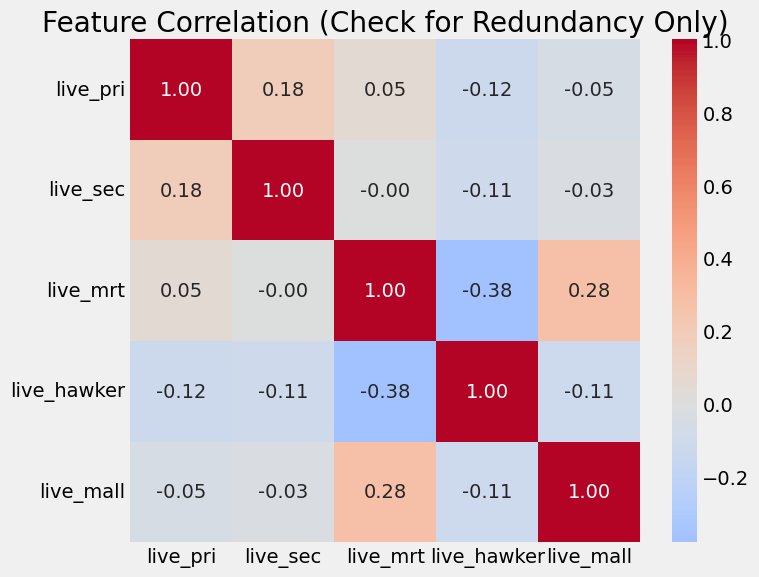


Highly correlated feature pairs (|r| > 0.8):
  None found - features are not highly correlated with each other.


In [13]:
# Optional: Check for redundant features (multicollinearity)
numeric_cols = df[FEATURES_TO_PLOT]
corr_matrix = numeric_cols.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=True, fmt='.2f')
plt.title('Feature Correlation (Check for Redundancy Only)')
plt.tight_layout()
plt.show()

# Flag highly correlated feature pairs (consider removing one)
CORRELATION_THRESHOLD = 0.8
print(f"\nHighly correlated feature pairs (|r| > {CORRELATION_THRESHOLD}):")
found_high_corr = False
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > CORRELATION_THRESHOLD:
            print(f"  {corr_matrix.columns[i]} & {corr_matrix.columns[j]} = {corr_matrix.iloc[i, j]:.2f}")
            found_high_corr = True
if not found_high_corr:
    print("  None found - features are not highly correlated with each other.")

---

## Step 5: Model Preprocessing

### 5a. Map Categorical Labels to Numeric Labels

In [14]:
# ========== MODIFY THIS ==========
TARGET_NUMERIC_COL = 'town_num'  # Name for the new numeric column
# =================================

# Map target to numeric values
df[TARGET_NUMERIC_COL] = df[TARGET_COLUMN].map(TARGET_MAPPING)

# Check for any unmapped values (NaN)
unmapped = df[df[TARGET_NUMERIC_COL].isna()][TARGET_COLUMN].unique()
if len(unmapped) > 0:
    print(f"WARNING: Unmapped values found: {unmapped}")
    print("Update TARGET_MAPPING to include these values.")
else:
    print("All target values successfully mapped!")

# Verify mapping
print("\nTarget mapping verification:")
print(df[[TARGET_COLUMN, TARGET_NUMERIC_COL]].drop_duplicates().sort_values(TARGET_NUMERIC_COL))

All target values successfully mapped!

Target mapping verification:
                 town  town_num
0          ANG MO KIO         0
98              BEDOK         1
208            BISHAN         2
248       BUKIT BATOK         3
333       BUKIT MERAH         4
415     BUKIT PANJANG         5
459       BUKIT TIMAH         6
464      CENTRAL AREA         7
473     CHOA CHU KANG         8
572          CLEMENTI         9
613           GEYLANG        10
678           HOUGANG        11
778       JURONG EAST        12
829       JURONG WEST        13
978   KALLANG/WHAMPOA        14
1030    MARINE PARADE        15
1043        PASIR RIS        16
1095          PUNGGOL        17
1175       QUEENSTOWN        18
1228        SEMBAWANG        19
1262         SENGKANG        20
1352        SERANGOON        21
1396         TAMPINES        22
1532        TOA PAYOH        23
1597        WOODLANDS        24
1774           YISHUN        25


### 5b. Define Feature Columns and Set X and y

In [15]:
# ========== MODIFY THIS ==========
# Use only the 5 liveability pillars for model training
PILLARS = ['live_pri', 'live_sec', 'live_mrt', 'live_hawker', 'live_mall']
df[PILLARS] = df[PILLARS].fillna(0)

TARGET_COLUMN = 'town'
FEATURE_COLUMNS = PILLARS
df = df.dropna(subset=[TARGET_COLUMN])
df[TARGET_COLUMN] = df[TARGET_COLUMN].astype(str)
# =================================

# Verify all features exist in dataframe
missing_cols = [col for col in FEATURE_COLUMNS if col not in df.columns]
if missing_cols:
    print(f"WARNING: Missing columns: {missing_cols}")
    print('Make sure to run the Feature Engineering cell (Step 3.5) first!')
else:
    print(f"All {len(FEATURE_COLUMNS)} features found in dataset")
    print(f"  - Features: {FEATURE_COLUMNS}")

# Create feature matrix (X) and target vector (y)
X = df[FEATURE_COLUMNS]
y = df[TARGET_NUMERIC_COL]

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")

All 5 features found in dataset
  - Features: ['live_pri', 'live_sec', 'live_mrt', 'live_hawker', 'live_mall']

X shape: (265409, 5)
y shape: (265409,)


In [16]:
# pd.concat([X, y], axis=1).to_csv('classification_first_permutation.csv', index=False)

### 5c. Split Data into Training and Testing Sets


In [ ]:
# ========== MODIFY THIS ==========
RANDOM_STATE = 42
TEST_SIZE = 0.25
# =================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

X_train = X_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

print(f"Training set size: {X_train.shape[0]:,} rows")
print(f"Testing set size:  {X_test.shape[0]:,} rows")
print(f"All towns in train? {y_train.nunique() == len(TARGET_MAPPING)}")
print(f"All towns in test?  {y_test.nunique() == len(TARGET_MAPPING)}")


Training set size: 199,056 rows
Testing set size:  66,353 rows
All towns in train? True
All towns in test?  True


### 5d. Feature Scaling with StandardScaler

**Why Scale?** KNN uses distance calculations, so features with larger scales can dominate the distance metric. StandardScaler normalizes features to have mean=0 and std=1.

In [18]:
# Initialize the scaler
scaler = StandardScaler()

# Fit on training data ONLY, then transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for easier inspection (optional)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=FEATURE_COLUMNS)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=FEATURE_COLUMNS)

print("Scaled training data statistics:")
print(X_train_scaled_df.describe().round(2))

Scaled training data statistics:
        live_pri   live_sec   live_mrt  live_hawker  live_mall
count  199056.00  199056.00  199056.00    199056.00  199056.00
mean        0.00       0.00      -0.00        -0.00      -0.00
std         1.00       1.00       1.00         1.00       1.00
min        -6.27      -9.92      -4.03        -3.28      -6.54
25%        -0.48      -0.46      -0.62        -0.41      -0.52
50%        -0.13       0.20      -0.23         0.29       0.05
75%         0.15       0.72       0.55         0.66       0.56
max         3.30       1.54       2.20         3.19       7.38


In [19]:
# ========== OPTIONAL SMOTE ON TRAINING DATA ==========
# Set True to oversample minority classes in TRAINING data only.
# IMPORTANT: This affects ALL downstream models, not just KNN,
# because Steps 6–14 use the same X_train/y_train variables.
USE_SMOTE = True
SMOTE_K_NEIGHBORS = 5
# ====================================================

import importlib

try:
    imblearn_over_sampling = importlib.import_module('imblearn.over_sampling')
    SMOTE = getattr(imblearn_over_sampling, 'SMOTE')
    smote_available = True
except ImportError:
    smote_available = False
    print("imblearn is not installed. Run: pip install imbalanced-learn")

# Refresh immutable backups from CURRENT split every run.
# This prevents stale backups if you changed split strategy in Step 5c.1.
_X_train_base = X_train.copy()
_y_train_base = y_train.copy()
_X_test_base = X_test.copy()
_y_test_base = y_test.copy()

# Always reset to base first
X_train = _X_train_base.copy()
y_train = _y_train_base.copy()
X_test = _X_test_base.copy()
y_test = _y_test_base.copy()

# Store pre-SMOTE frequencies
y_train_before_counts = pd.Series(y_train).value_counts().sort_index()
y_train_before_ratio = pd.Series(y_train).value_counts(normalize=True).sort_index()

if USE_SMOTE and smote_available:
    smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=SMOTE_K_NEIGHBORS)
    X_train, y_train = smote.fit_resample(X_train, y_train)
    print("SMOTE applied to TRAINING data.")
    print("Downstream impact: KNN + Random Forest + LightGBM + XGBoost + CatBoost all use SMOTE-resampled training data.")
else:
    if USE_SMOTE and not smote_available:
        print("SMOTE requested but imblearn is unavailable. Using original training data.")
    else:
        print("SMOTE disabled. Using original training data.")

# Post-SMOTE frequencies (or unchanged if disabled)
y_train_after_counts = pd.Series(y_train).value_counts().sort_index()
y_train_after_ratio = pd.Series(y_train).value_counts(normalize=True).sort_index()

# Explicit proof SMOTE is only applied to training data
print(f"\nTrain rows BEFORE SMOTE: {len(_y_train_base):,}")
print(f"Train rows AFTER  SMOTE: {len(y_train):,}")
print(f"Test rows (unchanged):   {len(y_test):,}")

# Refit scaler using the current training set (original or SMOTE-resampled)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Optional DataFrame views
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=FEATURE_COLUMNS)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=FEATURE_COLUMNS)

freq_df = pd.DataFrame({
    'Count Before SMOTE': y_train_before_counts,
    'Count After SMOTE': y_train_after_counts,
    'Pct Before SMOTE': (y_train_before_ratio * 100).round(2),
    'Pct After SMOTE': (y_train_after_ratio * 100).round(2),
}).fillna(0)

print("\nActual training class frequencies (before vs after SMOTE):")
print(freq_df.to_string())

print(f"\nTrain shape: {X_train.shape}")
print(f"Test shape:  {X_test.shape}")

SMOTE applied to TRAINING data.
Downstream impact: KNN + Random Forest + LightGBM + XGBoost + CatBoost all use SMOTE-resampled training data.

Train rows BEFORE SMOTE: 199,056
Train rows AFTER  SMOTE: 389,610
Test rows (unchanged):   66,353

Actual training class frequencies (before vs after SMOTE):
          Count Before SMOTE  Count After SMOTE  Pct Before SMOTE  Pct After SMOTE
town_num                                                                          
0                       8611              14985              4.33             3.85
1                      11139              14985              5.60             3.85
2                       3589              14985              1.80             3.85
3                       8380              14985              4.21             3.85
4                       7591              14985              3.81             3.85
5                       7103              14985              3.57             3.85
6                        482       

---

## Step 6: Find Optimal K Value

Iterate through different K values to find the one that minimizes testing error.

In [20]:
# ========== MODIFY THIS ==========
K_MIN = 1
K_MAX = 50
K_STEP = 2  # Use odd numbers to avoid ties
# =================================

# Calculate training and testing error for different K values
k_range = list(range(K_MIN, K_MAX, K_STEP))
training_error = []
testing_error = []

for k in k_range:
    # Instantiate and fit the model
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    
    # Calculate training error (error = 1 - accuracy)
    training_accuracy = knn.score(X_train_scaled, y_train)
    training_error.append(1 - training_accuracy)
    
    # Calculate testing error
    testing_accuracy = knn.score(X_test_scaled, y_test)
    testing_error.append(1 - testing_accuracy)

# Create results DataFrame
results_df = pd.DataFrame({
    'K': k_range,
    'training_error': training_error,
    'testing_error': testing_error,
    'training_accuracy': [1 - e for e in training_error],
    'testing_accuracy': [1 - e for e in testing_error]
}).set_index('K')

print("Top 10 K values (lowest testing error):")
print(results_df.sort_values('testing_error').head(10))

Top 10 K values (lowest testing error):
    training_error  testing_error  training_accuracy  testing_accuracy
K                                                                     
1         0.000000       0.000030           1.000000          0.999970
3         0.000018       0.000075           0.999982          0.999925
5         0.000054       0.000136           0.999946          0.999864
7         0.000126       0.000377           0.999874          0.999623
9         0.000244       0.000618           0.999756          0.999382
11        0.000344       0.000799           0.999656          0.999201
13        0.000526       0.001145           0.999474          0.998855
15        0.000698       0.001582           0.999302          0.998418
17        0.000896       0.001989           0.999104          0.998011
19        0.001209       0.002577           0.998791          0.997423


### Visualize Training vs Testing Error

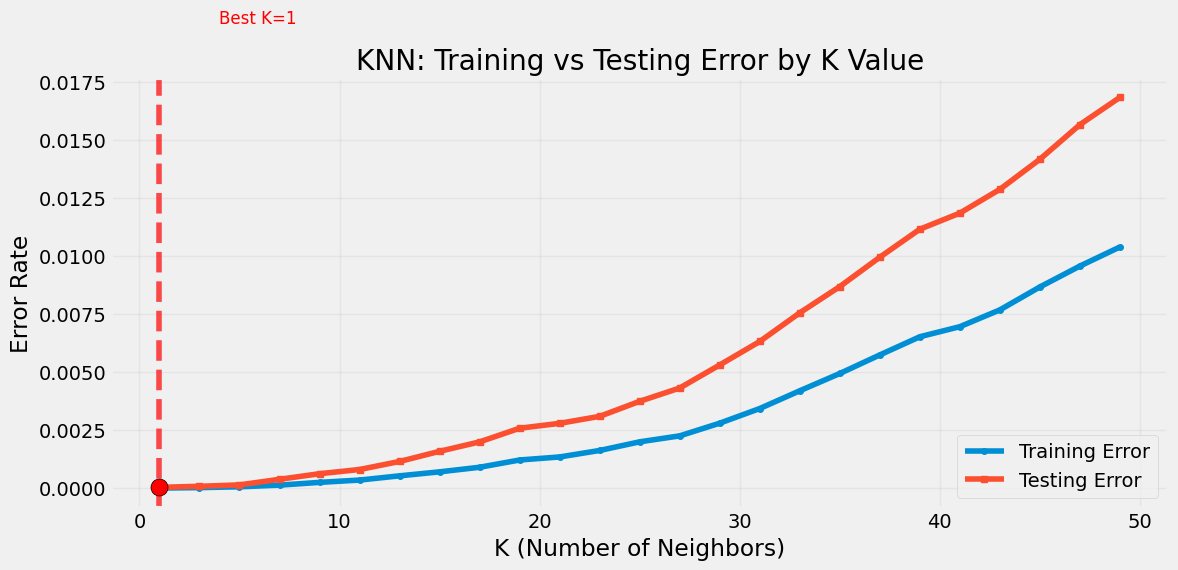


Optimal K value: 1
Testing error at K=1: 0.0000
Testing accuracy at K=1: 1.0000


In [21]:
# Plot error curves
plt.figure(figsize=(12, 6))
plt.plot(k_range, training_error, label='Training Error', marker='o', markersize=4)
plt.plot(k_range, testing_error, label='Testing Error', marker='s', markersize=4)
plt.xlabel('K (Number of Neighbors)')
plt.ylabel('Error Rate')
plt.title('KNN: Training vs Testing Error by K Value')
plt.legend()
plt.grid(True, alpha=0.3)

# Mark the optimal K
best_k = results_df['testing_error'].idxmin()
best_error = results_df.loc[best_k, 'testing_error']
plt.axvline(x=best_k, color='red', linestyle='--', alpha=0.7, label=f'Best K={best_k}')
plt.scatter([best_k], [best_error], color='red', s=150, zorder=5, edgecolor='black')
plt.annotate(f'Best K={best_k}', xy=(best_k, best_error), xytext=(best_k+3, best_error+0.02),
             fontsize=12, color='red')

plt.tight_layout()
plt.show()

print(f"\nOptimal K value: {best_k}")
print(f"Testing error at K={best_k}: {best_error:.4f}")
print(f"Testing accuracy at K={best_k}: {1 - best_error:.4f}")

---

## Step 7: Train Final Model and Evaluate

Train the model with the optimal K value and evaluate performance.

In [22]:
# Find best K from results
best_k = results_df['testing_error'].idxmin()

# Train final model
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_scaled, y_train)

# Calculate scores
train_accuracy = knn_final.score(X_train_scaled, y_train)
test_accuracy = knn_final.score(X_test_scaled, y_test)
train_error = 1 - train_accuracy
test_error = 1 - test_accuracy

# Display results
print("=" * 60)
print("                  FINAL MODEL PERFORMANCE")
print("=" * 60)
print(f"Best K Value: {best_k}")
print()
print(f"  train_accuracy: {train_accuracy:.4f}")
print(f"  test_accuracy:  {test_accuracy:.4f}")
print()
print(f"  train_error:    {train_error:.4f}")
print(f"  test_error:     {test_error:.4f}")
print("=" * 60)

                  FINAL MODEL PERFORMANCE
Best K Value: 1

  train_accuracy: 1.0000
  test_accuracy:  1.0000

  train_error:    0.0000
  test_error:     0.0000


### Detailed Classification Report

In [23]:
# Make predictions
y_pred = knn_final.predict(X_test_scaled)

# Get the class labels that are actually present in the data
present_classes = sorted(y.unique())
present_labels = [k for k, v in sorted(TARGET_MAPPING.items(), key=lambda x: x[1]) if v in present_classes]

# Classification report
print("Classification Report:")
print("="*60)
print(classification_report(y_test, y_pred, target_names=present_labels, zero_division=0))

Classification Report:
                 precision    recall  f1-score   support

     ANG MO KIO       1.00      1.00      1.00      2899
          BEDOK       1.00      1.00      1.00      3841
         BISHAN       1.00      1.00      1.00      1158
    BUKIT BATOK       1.00      1.00      1.00      2834
    BUKIT MERAH       1.00      1.00      1.00      2466
  BUKIT PANJANG       1.00      1.00      1.00      2423
    BUKIT TIMAH       1.00      1.00      1.00       147
   CENTRAL AREA       1.00      1.00      1.00       490
  CHOA CHU KANG       1.00      1.00      1.00      2822
       CLEMENTI       1.00      1.00      1.00      1540
        GEYLANG       1.00      1.00      1.00      1735
        HOUGANG       1.00      1.00      1.00      3446
    JURONG EAST       1.00      1.00      1.00      1439
    JURONG WEST       1.00      1.00      1.00      4617
KALLANG/WHAMPOA       1.00      1.00      1.00      2030
  MARINE PARADE       1.00      1.00      1.00       452
      P

Confusion Matrix:
[[2899    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0]
 [   0 3841    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0]
 [   0    0 1158    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0]
 [   0    0    0 2834    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0]
 [   0    0    0    0 2466    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0]
 [   0    0    0    0    0 2423    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0]
 [   0    0    0    0    0    0  147    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0]
 [   0    0    0    0    0    0    0 

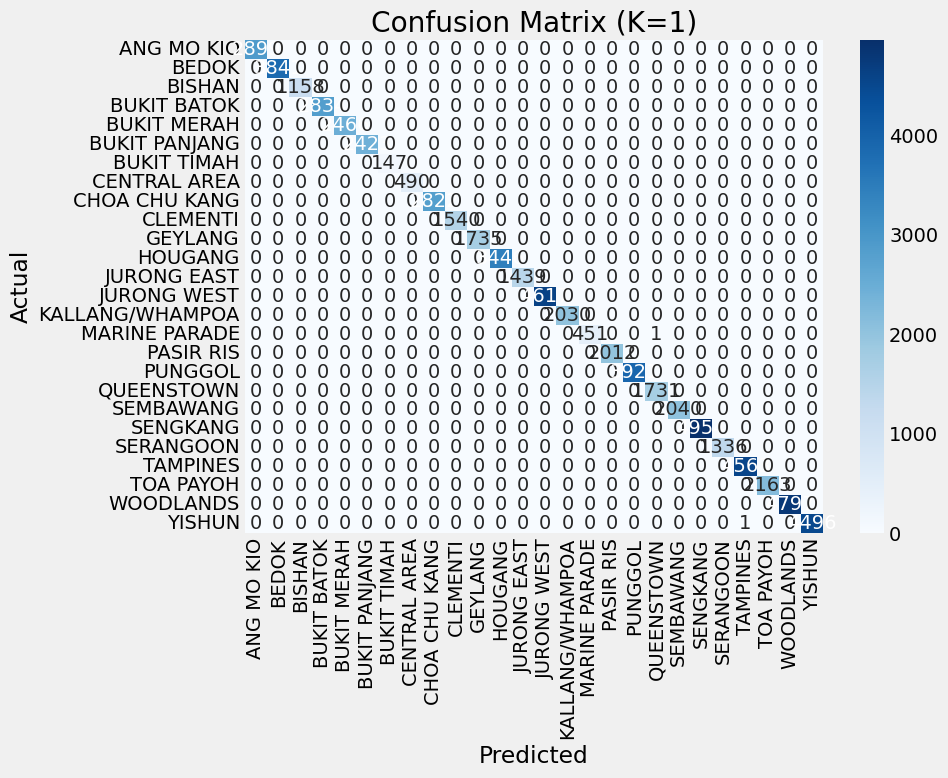

In [24]:
# Confusion matrix
print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Visualize confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=present_labels,
            yticklabels=present_labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix (K={best_k})')
plt.tight_layout()
plt.show()

---

## Step 8: Define Model Evaluation Helper Functions

Create reusable functions to train each classifier and display its performance — mirroring the same pattern used for each model in Steps 9–12.


In [25]:

def evaluate_classification_model(model, X_train, X_test, y_train, y_test, model_name, class_names):
    """
    Train a classification model and return evaluation metrics.

    Parameters
    ----------
    model        : sklearn-compatible classifier
    X_train/Test : feature DataFrames (raw, unscaled — tree models do not need scaling)
    y_train/test : target Series
    model_name   : display label
    class_names  : ordered list of class labels matching the numeric encoding

    Returns
    -------
    dict with Model, accuracies, errors, fitted_model, predictions,
         classification_report, and confusion_matrix.
    """
    model.fit(X_train, y_train)
    y_test_pred  = model.predict(X_test)
    y_train_pred = model.predict(X_train)

    # CatBoost returns float objects — cast to int so sklearn metrics work correctly
    if 'CatBoost' in type(model).__name__:
        y_test_pred  = np.array(y_test_pred).astype(int).ravel()
        y_train_pred = np.array(y_train_pred).astype(int).ravel()

    train_accuracy = model.score(X_train, y_train)
    test_accuracy  = model.score(X_test,  y_test)

    return {
        'Model':                 model_name,
        'Train Accuracy':        train_accuracy,
        'Test Accuracy':         test_accuracy,
        'Train Error':           1 - train_accuracy,
        'Test Error':            1 - test_accuracy,
        'fitted_model':          model,
        'y_test_pred':           y_test_pred,
        'classification_report': classification_report(
                                     y_test, y_test_pred,
                                     target_names=class_names,
                                     zero_division=0),
        'confusion_matrix':      confusion_matrix(y_test, y_test_pred),
    }


def display_classification_results(results):
    """Print a compact accuracy / error summary for one model."""
    print("=" * 90)
    print(f"  MODEL: {results['Model']}")
    print("=" * 90)
    print(f"  Train Accuracy : {results['Train Accuracy']:.4f}   |   Train Error : {results['Train Error']:.4f}")
    print(f"  Test  Accuracy : {results['Test Accuracy']:.4f}   |   Test  Error : {results['Test Error']:.4f}")
    print("=" * 90)
    print()


print("evaluate_classification_model() and display_classification_results() defined!")


evaluate_classification_model() and display_classification_results() defined!


In [26]:

# Prepare shared inputs used by every model evaluation cell (Steps 9–12).
# All models are evaluated on the SAME train/test split for a fair comparison.
# X_train, X_test, y_train, y_test were created in Step 5c.

# Class names — town labels in the same sorted order as the numeric encoding
class_names = [label for label, _ in sorted(TARGET_MAPPING.items(), key=lambda x: x[1])]

print(f"Shared train / test split : {len(X_train)} train | {len(X_test)} test")
print(f"Class names ({len(class_names)} towns)  : {class_names}")
print()
print("Note: KNN (Steps 6–7) uses X_train_scaled / X_test_scaled (scaling is")
print("      handled by its Pipeline).  Tree models below use raw X_train / X_test.")


Shared train / test split : 389610 train | 66353 test
Class names (26 towns)  : ['ANG MO KIO', 'BEDOK', 'BISHAN', 'BUKIT BATOK', 'BUKIT MERAH', 'BUKIT PANJANG', 'BUKIT TIMAH', 'CENTRAL AREA', 'CHOA CHU KANG', 'CLEMENTI', 'GEYLANG', 'HOUGANG', 'JURONG EAST', 'JURONG WEST', 'KALLANG/WHAMPOA', 'MARINE PARADE', 'PASIR RIS', 'PUNGGOL', 'QUEENSTOWN', 'SEMBAWANG', 'SENGKANG', 'SERANGOON', 'TAMPINES', 'TOA PAYOH', 'WOODLANDS', 'YISHUN']

Note: KNN (Steps 6–7) uses X_train_scaled / X_test_scaled (scaling is
      handled by its Pipeline).  Tree models below use raw X_train / X_test.


---

## Step 9a: Common parameters to modify


In [27]:
# MODIFY THIS CELL TO EVALUATE YOUR MODELS (Steps 9b–12)
N_ESTIMATORS = 300  # Number of trees in the forest (tune for better performance)

---

## Step 9b: Random Forest Model

An ensemble of decision trees that votes on the most likely class.  
No feature scaling required — Random Forest is scale-invariant.

In [28]:
# ========== RANDOM FOREST ==========
# Tree-based models are scale-invariant — use raw X_train / X_test from Step 5c.
rf_model = RandomForestClassifier(
    n_estimators=N_ESTIMATORS,
    random_state=RANDOM_STATE,
    class_weight='balanced_subsample',
    n_jobs=-1
)

rf_results = evaluate_classification_model(
    rf_model, X_train, X_test, y_train, y_test,
    'Random Forest', class_names
)

display_classification_results(rf_results)


  MODEL: Random Forest
  Train Accuracy : 1.0000   |   Train Error : 0.0000
  Test  Accuracy : 1.0000   |   Test  Error : 0.0000



Classification Report — Random Forest:
                 precision    recall  f1-score   support

     ANG MO KIO       1.00      1.00      1.00      2899
          BEDOK       1.00      1.00      1.00      3841
         BISHAN       1.00      1.00      1.00      1158
    BUKIT BATOK       1.00      1.00      1.00      2834
    BUKIT MERAH       1.00      1.00      1.00      2466
  BUKIT PANJANG       1.00      1.00      1.00      2423
    BUKIT TIMAH       1.00      1.00      1.00       147
   CENTRAL AREA       1.00      1.00      1.00       490
  CHOA CHU KANG       1.00      1.00      1.00      2822
       CLEMENTI       1.00      1.00      1.00      1540
        GEYLANG       1.00      1.00      1.00      1735
        HOUGANG       1.00      1.00      1.00      3446
    JURONG EAST       1.00      1.00      1.00      1439
    JURONG WEST       1.00      1.00      1.00      4617
KALLANG/WHAMPOA       1.00      1.00      1.00      2030
  MARINE PARADE       1.00      1.00      1.00  

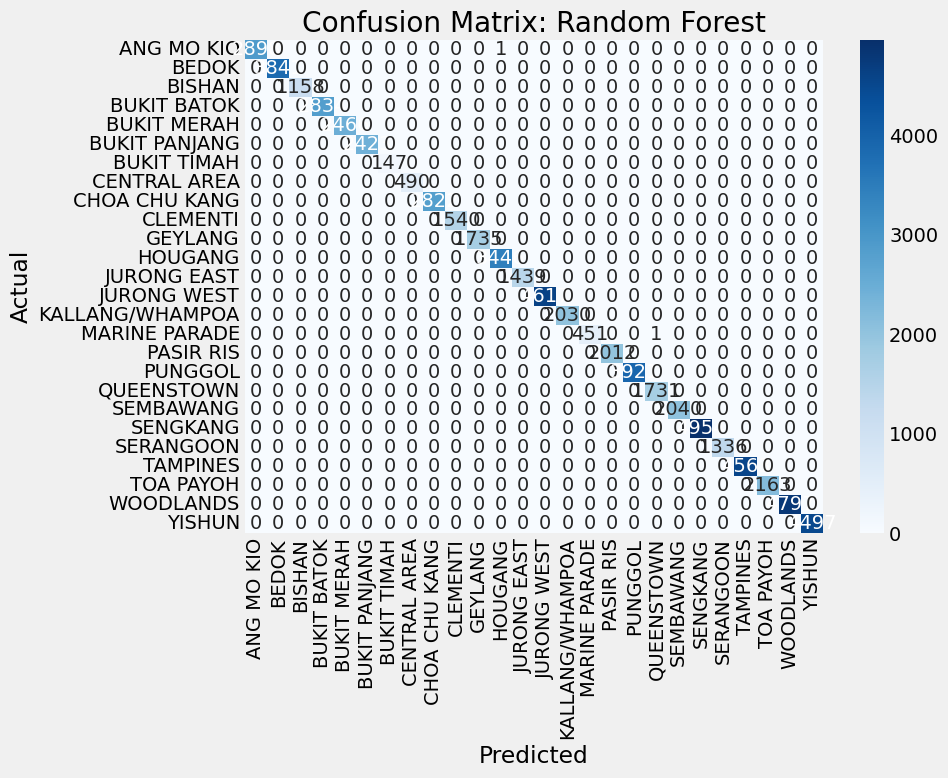

In [29]:

# Detailed Classification Report — Random Forest
print("Classification Report — Random Forest:")
print("=" * 90)
print(rf_results['classification_report'])
print("=" * 90)

# Confusion matrix heatmap
cm_rf = rf_results['confusion_matrix']
plt.figure(figsize=(10, 8))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Random Forest')
plt.tight_layout()
plt.show()


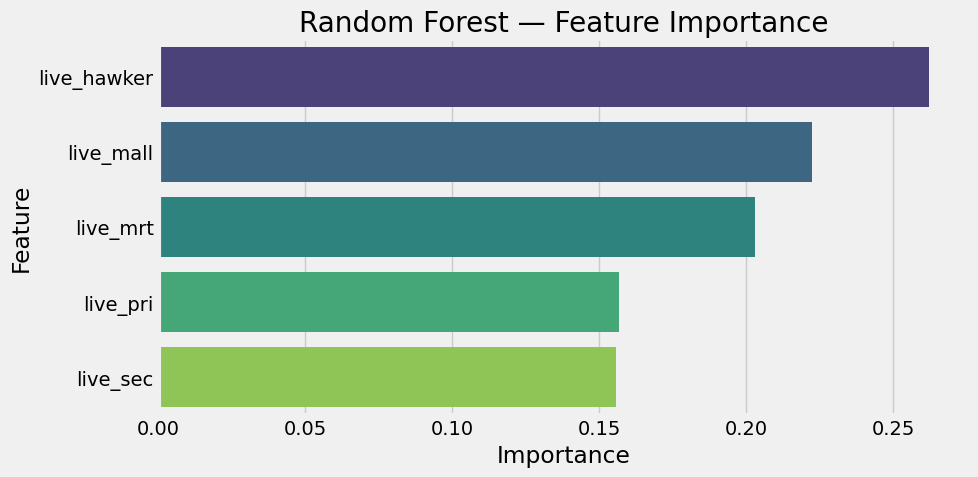

Feature Importance:
    Feature  Importance
live_hawker    0.262301
  live_mall    0.222360
   live_mrt    0.203110
   live_pri    0.156743
   live_sec    0.155487


In [30]:

# Feature importance — Random Forest
# Higher importance means the model relies more on that feature when splitting trees.
rf_importance = pd.DataFrame({
    'Feature':    FEATURE_COLUMNS,
    'Importance': rf_results['fitted_model'].feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=rf_importance, x='Importance', y='Feature', palette='viridis')
plt.title('Random Forest — Feature Importance')
plt.tight_layout()
plt.show()

print("Feature Importance:")
print(rf_importance.to_string(index=False))


---

## Step 10: LightGBM Model

Gradient boosting with fast leaf-wise tree growth.  
No feature scaling required — LightGBM is scale-invariant.


In [31]:

# ========== LIGHTGBM ==========
if LGBMClassifier is not None:
    lgbm_model = LGBMClassifier(
        objective='multiclass',
        num_class=len(TARGET_MAPPING),
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=63,
        max_depth=6,
        min_child_samples=10,
        subsample=0.9,
        colsample_bytree=0.9,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    lgbm_results = evaluate_classification_model(
        lgbm_model, X_train, X_test, y_train, y_test,
        'LightGBM', class_names
    )
    display_classification_results(lgbm_results)
else:
    print("LightGBM is not installed. Run:  pip install lightgbm")
    lgbm_results = None


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001953 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 389610, number of used features: 5
[LightGBM] [Info] Start training from score -3.258097
[LightGBM] [Info] Start training from score -3.258097
[LightGBM] [Info] Start training from score -3.258097
[LightGBM] [Info] Start training from score -3.258097
[LightGBM] [Info] Start training from score -3.258097
[LightGBM] [Info] Start training from score -3.258097
[LightGBM] [Info] Start training from score -3.258097
[LightGBM] [Info] Start training from score -3.258097
[LightGBM] [Info] Start training from score -3.258097
[LightGBM] [Info] Start training from score -3.258097
[LightGBM] [Info] Start training from score -3.258097
[LightGBM] [Info] Start training from score -3.258097

Classification Report — LightGBM:
                 precision    recall  f1-score   support

     ANG MO KIO       1.00      1.00      1.00      2899
          BEDOK       1.00      1.00      1.00      3841
         BISHAN       1.00      1.00      1.00      1158
    BUKIT BATOK       1.00      1.00      1.00      2834
    BUKIT MERAH       1.00      1.00      1.00      2466
  BUKIT PANJANG       1.00      1.00      1.00      2423
    BUKIT TIMAH       1.00      1.00      1.00       147
   CENTRAL AREA       1.00      1.00      1.00       490
  CHOA CHU KANG       1.00      1.00      1.00      2822
       CLEMENTI       1.00      1.00      1.00      1540
        GEYLANG       1.00      1.00      1.00      1735
        HOUGANG       1.00      1.00      1.00      3446
    JURONG EAST       1.00      1.00      1.00      1439
    JURONG WEST       1.00      1.00      1.00      4617
KALLANG/WHAMPOA       1.00      1.00      1.00      2030
  MARINE PARADE       1.00      1.00      1.00       

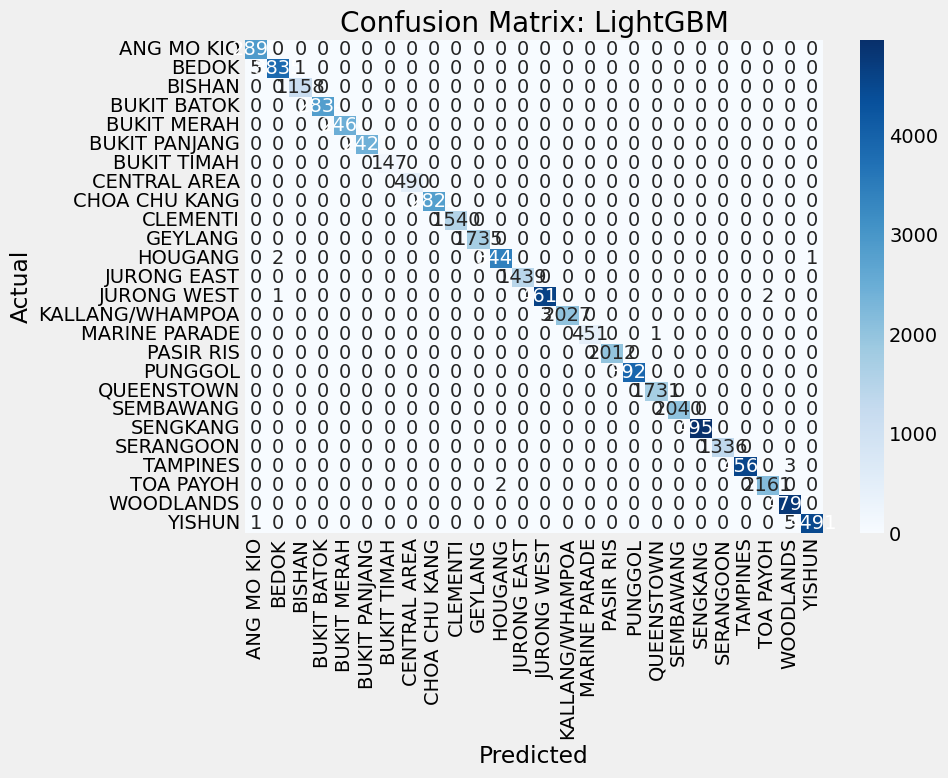

In [32]:

# Detailed Classification Report — LightGBM
if globals().get('lgbm_results') is not None:
    print("Classification Report — LightGBM:")
    print("=" * 90)
    print(lgbm_results['classification_report'])
    print("=" * 90)

    cm_lgbm = lgbm_results['confusion_matrix']
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_lgbm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix: LightGBM')
    plt.tight_layout()
    plt.show()


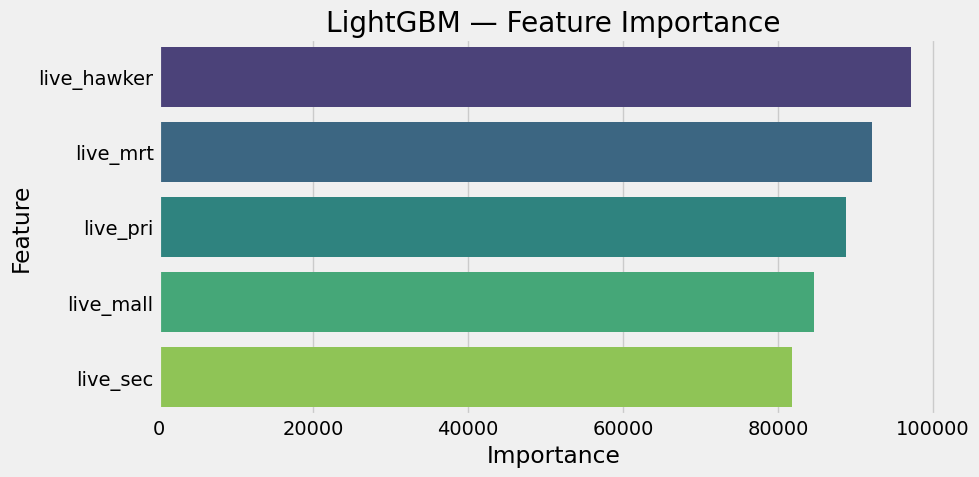

Feature Importance:
    Feature  Importance
live_hawker       97159
   live_mrt       92172
   live_pri       88787
  live_mall       84597
   live_sec       81873


In [33]:

# Feature importance — LightGBM
if globals().get('lgbm_results') is not None:
    lgbm_importance = pd.DataFrame({
        'Feature':    FEATURE_COLUMNS,
        'Importance': lgbm_results['fitted_model'].feature_importances_
    }).sort_values('Importance', ascending=False)

    plt.figure(figsize=(10, 5))
    sns.barplot(data=lgbm_importance, x='Importance', y='Feature', palette='viridis')
    plt.title('LightGBM — Feature Importance')
    plt.tight_layout()
    plt.show()

    print("Feature Importance:")
    print(lgbm_importance.to_string(index=False))


---

## Step 11: XGBoost Model

Gradient boosting with level-wise tree growth and built-in regularisation (L1/L2).  
No feature scaling required — XGBoost is scale-invariant.


In [34]:

# ========== XGBOOST ==========
if XGBClassifier is not None:
    xgb_model = XGBClassifier(
        n_estimators=N_ESTIMATORS,          # Number of boosting trees (more trees can improve fit but increase training time)
        learning_rate=0.05,        # Step size shrinkage per tree (lower = slower but often more stable learning)
        max_depth=6,               # Maximum depth of each tree (controls model complexity)
        subsample=0.9,             # Fraction of training rows sampled per tree (adds randomness, helps reduce overfitting)
        colsample_bytree=0.9,      # Fraction of features sampled per tree (reduces correlation between trees)
        objective='multi:softmax', # Multiclass objective that outputs class labels directly
        num_class=len(TARGET_MAPPING),  # Total number of target classes for multiclass training
        random_state=RANDOM_STATE, # Reproducibility: same random seed gives same results
        n_jobs=-1,                 # Use all CPU cores for faster training
        eval_metric='mlogloss'     # Evaluation metric: multiclass log loss (lower is better)
    )
    xgb_results = evaluate_classification_model(
        xgb_model, X_train, X_test, y_train, y_test,
        'XGBoost', class_names
    )
    display_classification_results(xgb_results)
else:
    print("XGBoost is not installed. Run:  pip install xgboost")
    xgb_results = None


  MODEL: XGBoost
  Train Accuracy : 0.9852   |   Train Error : 0.0148
  Test  Accuracy : 0.9718   |   Test  Error : 0.0282



Classification Report — XGBoost:
                 precision    recall  f1-score   support

     ANG MO KIO       0.83      0.98      0.90      2899
          BEDOK       0.97      0.98      0.98      3841
         BISHAN       1.00      1.00      1.00      1158
    BUKIT BATOK       0.98      1.00      0.99      2834
    BUKIT MERAH       1.00      0.98      0.99      2466
  BUKIT PANJANG       0.99      1.00      0.99      2423
    BUKIT TIMAH       1.00      1.00      1.00       147
   CENTRAL AREA       1.00      1.00      1.00       490
  CHOA CHU KANG       1.00      1.00      1.00      2822
       CLEMENTI       0.94      1.00      0.97      1540
        GEYLANG       1.00      1.00      1.00      1735
        HOUGANG       0.98      0.99      0.99      3446
    JURONG EAST       1.00      1.00      1.00      1439
    JURONG WEST       0.97      0.92      0.95      4617
KALLANG/WHAMPOA       0.99      1.00      0.99      2030
  MARINE PARADE       0.99      1.00      0.99       4

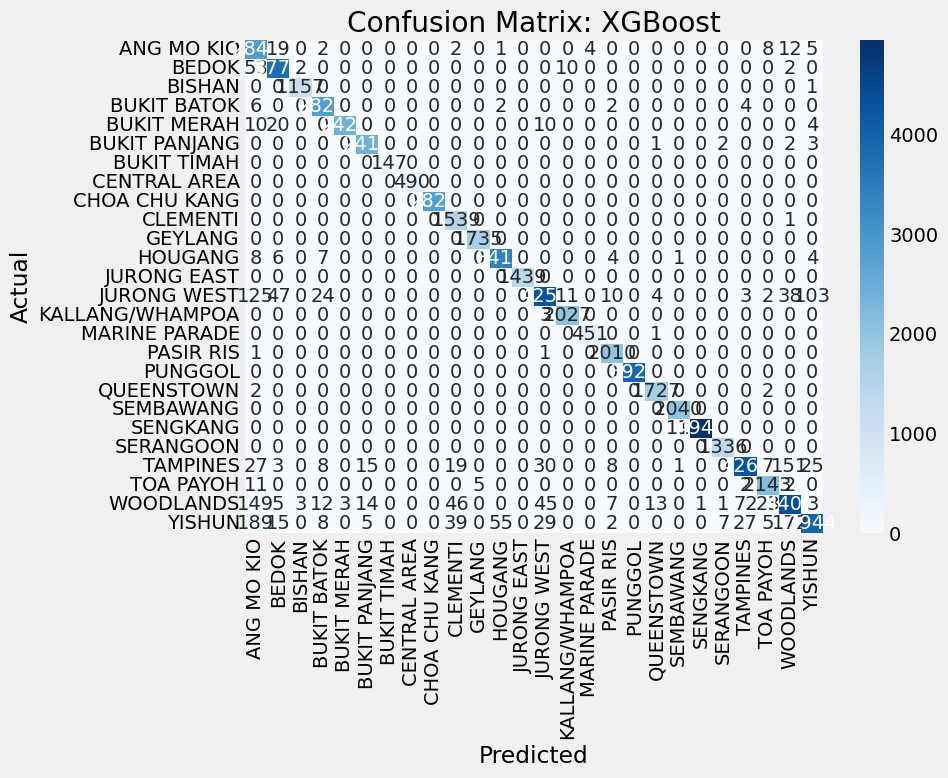

In [35]:

# Detailed Classification Report — XGBoost
if globals().get('xgb_results') is not None:
    print("Classification Report — XGBoost:")
    print("=" * 90)
    print(xgb_results['classification_report'])
    print("=" * 90)

    cm_xgb = xgb_results['confusion_matrix']
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix: XGBoost')
    plt.tight_layout()
    plt.show()


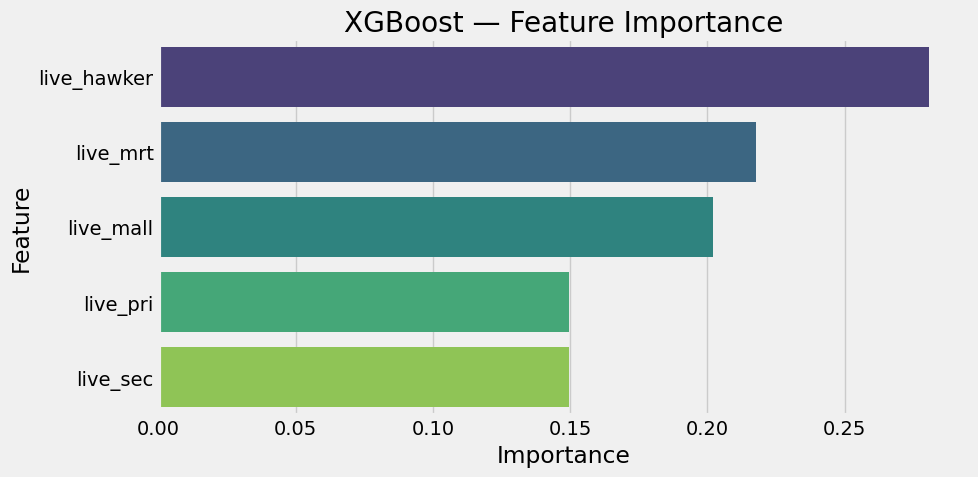

Feature Importance:
    Feature  Importance
live_hawker    0.280903
   live_mrt    0.217858
  live_mall    0.202122
   live_pri    0.149654
   live_sec    0.149464


In [36]:

# Feature importance — XGBoost
if globals().get('xgb_results') is not None:
    xgb_importance = pd.DataFrame({
        'Feature':    FEATURE_COLUMNS,
        'Importance': xgb_results['fitted_model'].feature_importances_
    }).sort_values('Importance', ascending=False)

    plt.figure(figsize=(10, 5))
    sns.barplot(data=xgb_importance, x='Importance', y='Feature', palette='viridis')
    plt.title('XGBoost — Feature Importance')
    plt.tight_layout()
    plt.show()

    print("Feature Importance:")
    print(xgb_importance.to_string(index=False))


---

## Step 12: CatBoost Model

Gradient boosting with built-in handling for class imbalance.  
No feature scaling required — CatBoost is scale-invariant.


In [37]:

# ========== CATBOOST ==========
if CatBoostClassifier is not None:
    catboost_model = CatBoostClassifier(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        loss_function='MultiClass',
        eval_metric='Accuracy',
        random_seed=RANDOM_STATE,
        verbose=0
    )
    catboost_results = evaluate_classification_model(
        catboost_model, X_train, X_test, y_train, y_test,
        'CatBoost', class_names
    )
    display_classification_results(catboost_results)
else:
    print("CatBoost is not installed. Run:  pip install catboost")
    catboost_results = None


  MODEL: CatBoost
  Train Accuracy : 0.9402   |   Train Error : 0.0598
  Test  Accuracy : 0.9085   |   Test  Error : 0.0915



Classification Report — CatBoost:
                 precision    recall  f1-score   support

     ANG MO KIO       0.66      0.91      0.77      2899
          BEDOK       0.90      0.87      0.89      3841
         BISHAN       0.96      0.97      0.96      1158
    BUKIT BATOK       0.92      0.93      0.92      2834
    BUKIT MERAH       0.97      0.89      0.93      2466
  BUKIT PANJANG       0.88      0.96      0.92      2423
    BUKIT TIMAH       1.00      1.00      1.00       147
   CENTRAL AREA       0.99      1.00      1.00       490
  CHOA CHU KANG       0.99      0.99      0.99      2822
       CLEMENTI       0.77      0.97      0.86      1540
        GEYLANG       0.97      0.98      0.97      1735
        HOUGANG       0.94      0.91      0.93      3446
    JURONG EAST       0.98      1.00      0.99      1439
    JURONG WEST       0.94      0.82      0.87      4617
KALLANG/WHAMPOA       0.93      0.99      0.96      2030
  MARINE PARADE       0.98      0.99      0.98       

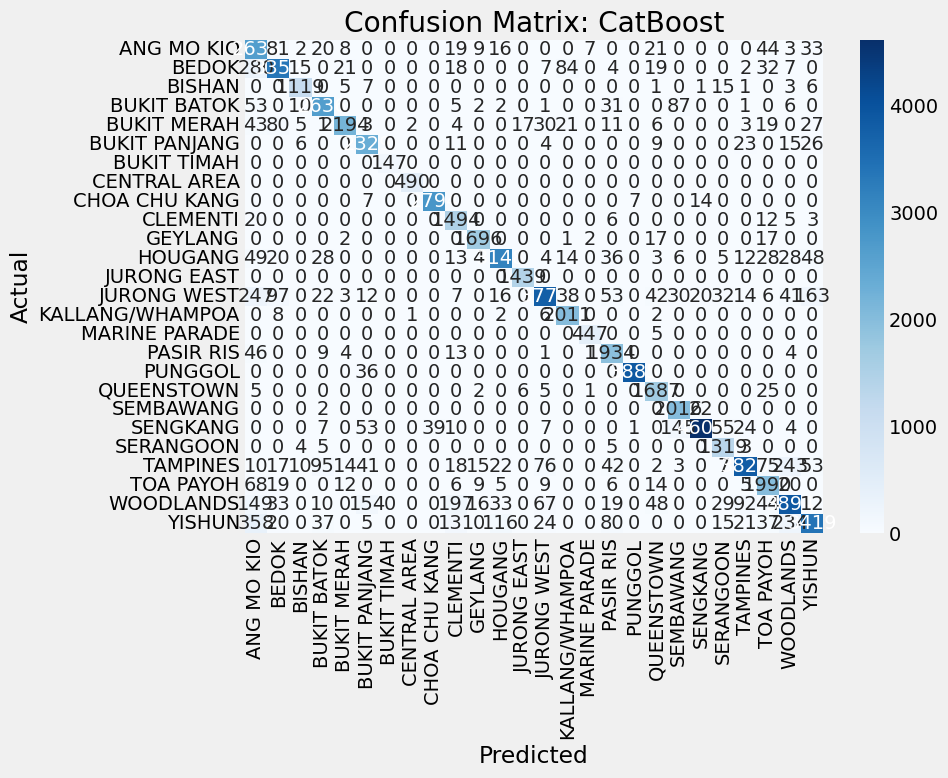

In [38]:

# Detailed Classification Report — CatBoost
if globals().get('catboost_results') is not None:
    print("Classification Report — CatBoost:")
    print("=" * 90)
    print(catboost_results['classification_report'])
    print("=" * 90)

    cm_catboost = catboost_results['confusion_matrix']
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_catboost, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix: CatBoost')
    plt.tight_layout()
    plt.show()


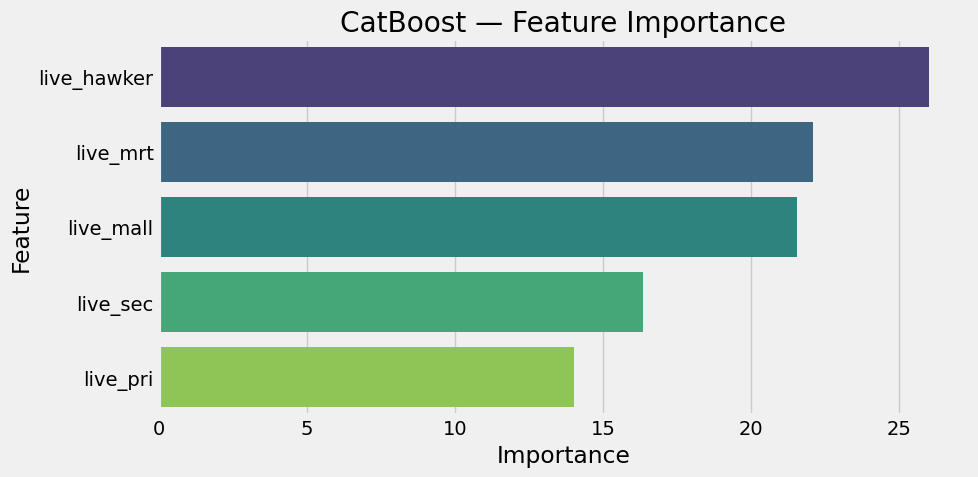

Feature Importance:
    Feature  Importance
live_hawker   26.016402
   live_mrt   22.102708
  live_mall   21.532719
   live_sec   16.335409
   live_pri   14.012762


In [39]:

# Feature importance — CatBoost
if globals().get('catboost_results') is not None:
    catboost_importance = pd.DataFrame({
        'Feature':    FEATURE_COLUMNS,
        'Importance': catboost_results['fitted_model'].feature_importances_
    }).sort_values('Importance', ascending=False)

    plt.figure(figsize=(10, 5))
    sns.barplot(data=catboost_importance, x='Importance', y='Feature', palette='viridis')
    plt.title('CatBoost — Feature Importance')
    plt.tight_layout()
    plt.show()

    print("Feature Importance:")
    print(catboost_importance.to_string(index=False))


---

## Step 13: Model Comparison Summary

Rank all trained models side-by-side on the same train/test split.


In [40]:

# Collect all trained model results for comparison.
# KNN metrics come from the variables produced in Steps 6-7.
knn_train_acc = knn_final.score(X_train_scaled, y_train)
knn_test_acc  = knn_final.score(X_test_scaled,  y_test)

all_comparison_results = [
    {
        'Model':          f'KNN (k={best_k})',
        'Train Accuracy': knn_train_acc,
        'Test Accuracy':  knn_test_acc,
        'Train Error':    1 - knn_train_acc,
        'Test Error':     1 - knn_test_acc,
    },
    rf_results,
]

for res in [
    globals().get('lgbm_results'),
    globals().get('xgb_results'),
    globals().get('catboost_results'),
]:
    if res is not None:
        all_comparison_results.append(res)

comparison_df = pd.DataFrame([
    {
        'Model':          r['Model'],
        'Train Accuracy': round(r['Train Accuracy'], 4),
        'Test Accuracy':  round(r['Test Accuracy'],  4),
        'Train Error':    round(r['Train Error'],     4),
        'Test Error':     round(r['Test Error'],      4),
    }
    for r in all_comparison_results
]).sort_values('Test Accuracy', ascending=False).reset_index(drop=True)

print("=" * 90)
print(f"                    MODEL COMPARISON SUMMARY ({len(comparison_df)} Models)")
print("=" * 90)
print(comparison_df.to_string(index=False))
print("\n" + "=" * 90)
print(f"  Best Predicting Model: {comparison_df.loc[0, 'Model']}")
print("=" * 90)


                    MODEL COMPARISON SUMMARY (5 Models)
        Model  Train Accuracy  Test Accuracy  Train Error  Test Error
    KNN (k=1)          1.0000         1.0000       0.0000      0.0000
Random Forest          1.0000         1.0000       0.0000      0.0000
     LightGBM          0.9999         0.9996       0.0001      0.0004
      XGBoost          0.9852         0.9718       0.0148      0.0282
     CatBoost          0.9402         0.9085       0.0598      0.0915

  Best Predicting Model: KNN (k=1)


MODEL DISCREPANCY SCORES
        Model  Train Accuracy  Test Accuracy  Accuracy Gap  Train Error  Test Error  Error Gap  Abs Accuracy Gap
     CatBoost          0.9402         0.9085        0.0317       0.0598      0.0915     0.0317            0.0317
      XGBoost          0.9852         0.9718        0.0134       0.0148      0.0282     0.0134            0.0134
     LightGBM          0.9999         0.9996        0.0003       0.0001      0.0004     0.0003            0.0003
    KNN (k=1)          1.0000         1.0000        0.0000       0.0000      0.0000     0.0000            0.0000
Random Forest          1.0000         1.0000        0.0000       0.0000      0.0000     0.0000            0.0000


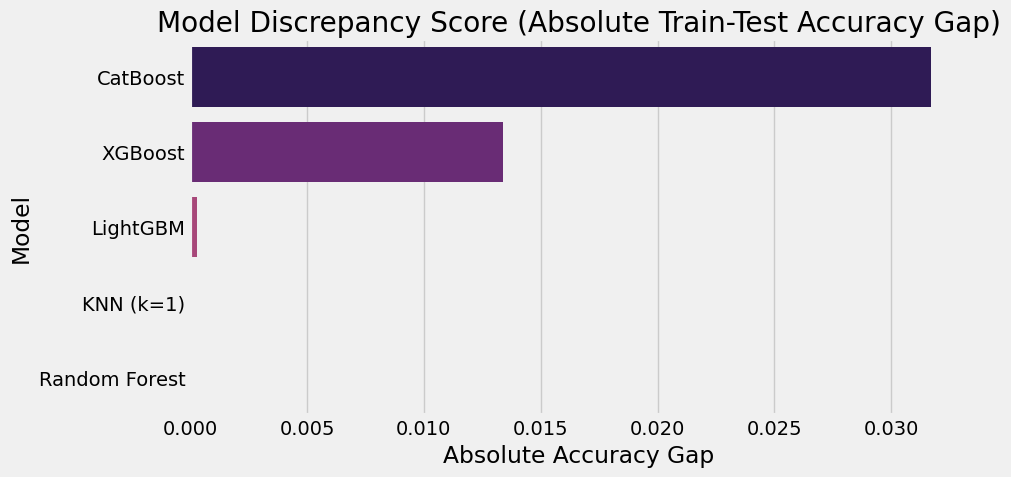


Most discrepant model:
CatBoost | Accuracy Gap = 0.0317


In [41]:
# Discrepancy scores: compare train vs test performance for each model

discrepancy_df = comparison_df.copy()
discrepancy_df['Accuracy Gap'] = (
    discrepancy_df['Train Accuracy'] - discrepancy_df['Test Accuracy']
).round(4)
discrepancy_df['Error Gap'] = (
    discrepancy_df['Test Error'] - discrepancy_df['Train Error']
).round(4)
discrepancy_df['Abs Accuracy Gap'] = discrepancy_df['Accuracy Gap'].abs().round(4)

discrepancy_df = discrepancy_df.sort_values(
    'Abs Accuracy Gap', ascending=False
).reset_index(drop=True)

print('=' * 90)
print('MODEL DISCREPANCY SCORES')
print('=' * 90)
print(discrepancy_df[[
    'Model',
    'Train Accuracy',
    'Test Accuracy',
    'Accuracy Gap',
    'Train Error',
    'Test Error',
    'Error Gap',
    'Abs Accuracy Gap',
]].to_string(index=False))

plt.figure(figsize=(10, 5))
sns.barplot(
    data=discrepancy_df,
    x='Abs Accuracy Gap',
    y='Model',
    palette='magma'
)
plt.title('Model Discrepancy Score (Absolute Train-Test Accuracy Gap)')
plt.xlabel('Absolute Accuracy Gap')
plt.ylabel('Model')
plt.tight_layout()
plt.show()

most_discrepant = discrepancy_df.iloc[0]
print('\nMost discrepant model:')
print(f"{most_discrepant['Model']} | Accuracy Gap = {most_discrepant['Accuracy Gap']:.4f}")

In [42]:
# You can only display model runtimes without rerunning IF you already captured them earlier.
# This cell will check whether those runtime variables already exist in memory.

import pandas as pd
import numpy as np

runtime_lookup = {
    f'KNN (K={best_k})' if 'best_k' in globals() else 'KNN': globals().get('knn_runtime', None),
    'Random Forest': globals().get('rf_runtime', None),
    'LightGBM': globals().get('lgbm_runtime', None),
    'XGBoost': globals().get('xgb_runtime', None),
    'CatBoost': globals().get('catboost_runtime', None)
}

runtime_rows = []
for model_name, runtime_value in runtime_lookup.items():
    runtime_rows.append({
        'Split': ACTIVE_SPLIT if 'ACTIVE_SPLIT' in globals() else 'unknown',
        'Model': model_name,
        'Runtime (sec)': runtime_value,
        'Runtime (min)': None if runtime_value is None else runtime_value / 60
    })

runtime_df = pd.DataFrame(runtime_rows)

if runtime_df['Runtime (sec)'].notna().any():
    total_runtime = runtime_df['Runtime (sec)'].dropna().sum()
    runtime_df['Runtime (sec)'] = runtime_df['Runtime (sec)'].round(4)
    runtime_df['Runtime (min)'] = runtime_df['Runtime (min)'].round(4)

    display(runtime_df)

    print("=" * 90)
    print(f"TOTAL MODEL RUNTIME : {total_runtime:.4f} sec ({total_runtime/60:.4f} min)")
    print("=" * 90)
else:
    print("=" * 90)
    print("No saved runtime values were found in memory.")
    print("That means the notebook did not record the training runtime when the models were run.")
    print("So the exact runtime for each model cannot be displayed now without rerunning them.")
    print("=" * 90)

No saved runtime values were found in memory.
That means the notebook did not record the training runtime when the models were run.
So the exact runtime for each model cannot be displayed now without rerunning them.


# ========== EXPORT CLASSIFICATION MODEL AND ARTEFACTS TO WEB APP ==========
# Run this cell after training to update app/models/ with the latest model.
# The web app (app/app.py) reads these files at startup.
import joblib
import json
from pathlib import Path

MODEL_DIR = Path("../app/models")
MODEL_DIR.mkdir(exist_ok=True)

# 1. Save the best classifier (Random Forest)
joblib.dump(rf_results["fitted_model"], MODEL_DIR / "rf_classifier.joblib")
print("Saved: rf_classifier.joblib")

# 2. Save the fitted scaler (used to scale features before prediction)
joblib.dump(scaler, MODEL_DIR / "scaler_classifier.joblib")
print("Saved: scaler_classifier.joblib")

# 3. Save the town class labels (index maps to town name, e.g. class 0 -> class_names[0])
with open(MODEL_DIR / "town_classes.json", "w") as f:
    json.dump(class_names, f, indent=2)
print(f"Saved: town_classes.json  ({len(class_names)} towns)")
for i, town in enumerate(class_names):
    print(f"  {i}: {town}")

print("All classification artefacts exported to app/models/")


---

## Summary

| Step | Model | Type | Notes |
|------|-------|------|-------|
| Step 6–7 | KNN | Distance-based | Tuned via K search; requires feature scaling via Pipeline |
| Step 9   | Random Forest | Ensemble | 300 trees; balanced class weights; scale-invariant |
| Step 10  | LightGBM | Gradient Boosting | Fast leaf-wise growth; scale-invariant |
| Step 11  | XGBoost | Gradient Boosting | Level-wise with regularisation; scale-invariant |
| Step 12  | CatBoost | Gradient Boosting | Handles class imbalance; scale-invariant |
| Step 13  | Comparison | — | All models ranked on the same train/test split |
| Step 14  | Gallery | — | Confusion matrix per model for visual error analysis |

**How to reuse this notebook on a new dataset:**
1. Update `TARGET_COLUMN` and `DATA_PATH` in Steps 1–2
2. Adjust `FEATURE_COLUMNS` in Step 5b (and feature engineering in Step 3.5)
3. Re-run all cells — Steps 6–14 train and compare all models automatically


In [ ]:
import imblearn
from imblearn.over_sampling import SMOTE

print('imblearn version:', imblearn.__version__)
print('SMOTE import successful')

imblearn version: 0.14.1
SMOTE import successful
